<h1><b>Завдання 1</b></h1>

In [1]:
from tensorflow import keras
from keras.layers import Conv2D,Dropout,MaxPooling2D,Flatten,Dense
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.models import Sequential
import numpy as np


In [2]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [4]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

y_train_categorical = to_categorical(y_train,10)
y_test_categorical = to_categorical(y_test,10)

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

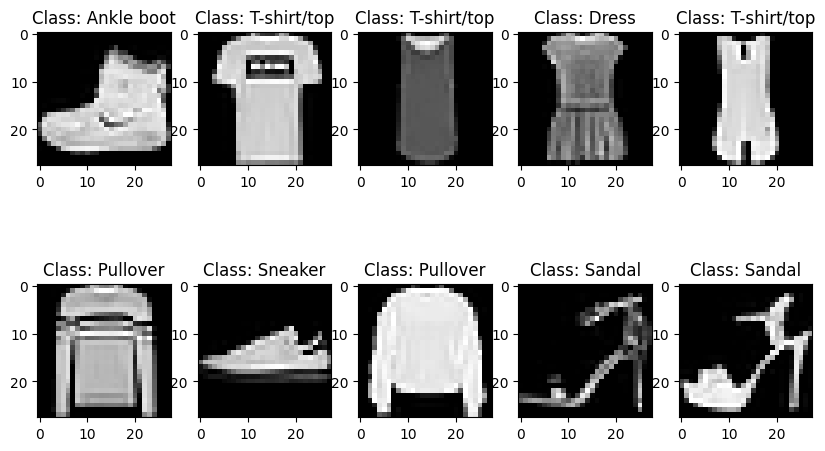

In [6]:
plt.figure(figsize=(10, 6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f'Class: {class_names[y_train[i]]}')

plt.show()

In [7]:
model = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(64,(3,3),activation="relu"),
    Dropout(0.2),

    Flatten(),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
early_stopping = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
history = model.fit(x_train,y_train_categorical,
                    epochs=100,
                    batch_size=128,
                    validation_data=(x_test,y_test_categorical),
                    callbacks=[early_stopping,reduce_lr])

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6288 - loss: 1.0107 - val_accuracy: 0.8212 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8251 - loss: 0.4733 - val_accuracy: 0.8600 - val_loss: 0.3837 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8574 - loss: 0.3856 - val_accuracy: 0.8801 - val_loss: 0.3362 - learning_rate: 0.0010
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8731 - loss: 0.3452 - val_accuracy: 0.8859 - val_loss: 0.3153 - learning_rate: 0.0010
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8793 - loss: 0.3267 - val_accuracy: 0.8925 - val_loss: 0.2960 - learning_rate: 0.0010
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8892 - loss: 0.3019 - val_accuracy: 0.8955 - val_loss: 0.2918 - learning_rate: 0.0010
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8921 - loss: 

/tmp/ipython-input-3187115810.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
/tmp/ipython-input-3187115810.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')


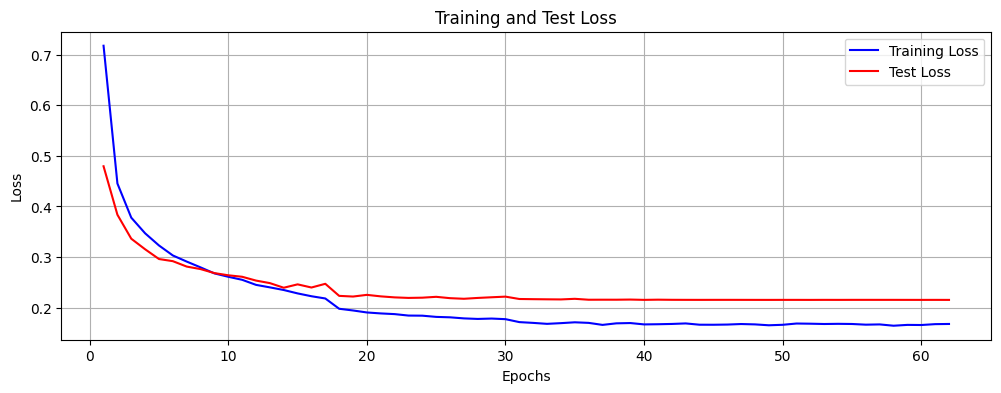

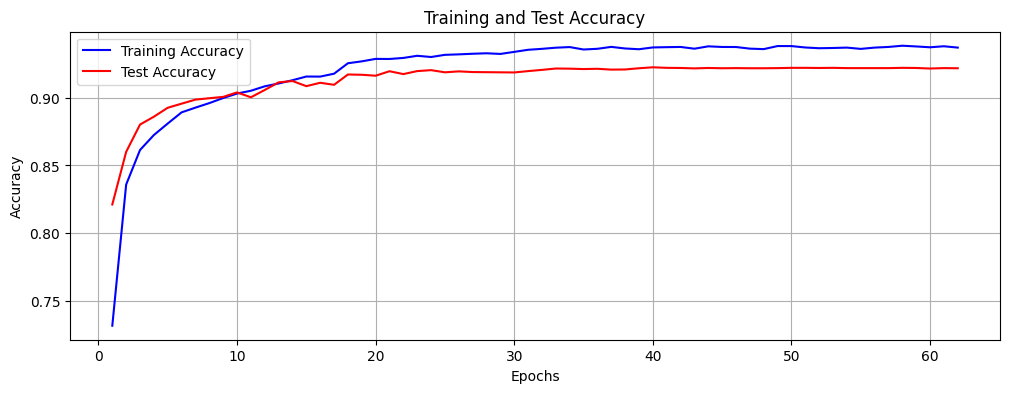

In [11]:
plt.figure(figsize=(12, 4))
loss_values=history.history['loss']
test_loss_values=history.history['val_loss']
epochs=range(1,len(history.history['loss'])+1)
plt.plot(epochs,loss_values,'b',label='Training Loss')
plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()



plt.figure(figsize=(12, 4))
loss_values=history.history['accuracy']
test_loss_values=history.history['val_accuracy']
epochs=range(1,len(history.history['accuracy'])+1)
plt.plot(epochs,loss_values,'b',label='Training Accuracy')
plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [12]:
results = model.evaluate(x_test, y_test_categorical)
print(results)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9197 - loss: 0.2259
[0.21513350307941437, 0.9218000173568726]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


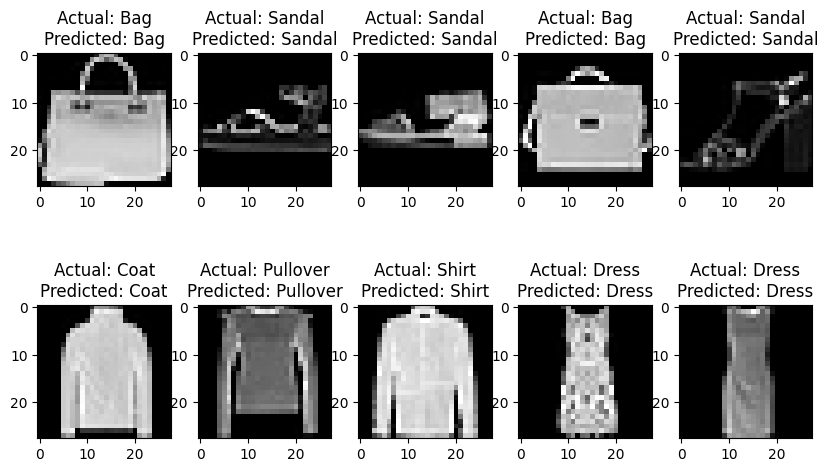

In [13]:
y_predict = model.predict(x_test)

random_index = np.random.choice(x_test.shape[0],10,replace=False)

plt.figure(figsize=(10, 6))

for i,index in enumerate(random_index):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
  plt.title(f'Actual: {class_names[y_test[index]]}\nPredicted: {class_names[np.argmax(y_predict[index])]}')

plt.show()

За допомогою згорткової мережі вдалося покращити точні до 92% порівняну з багатошаровою мережею у якої була тачність 89%. Ця мережа більше узагальнює і краще підходить для використання в майбутньому.